In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca data FIFA Players dari Drive
df_fifa = pd.read_csv('/content/drive/MyDrive/CAPSTONE 2/fifa_players.csv')

# Menampilkan data teratas
df_fifa.head(100)

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,G. Kondogbia,Geoffrey Kondogbia,2/15/1993,26,187.96,79.8,"CM,CDM",Central African Rep.,81,84,...,80,82,79,77,79,45,82,78,82,82
96,J. Roussillon,Jérôme Roussillon,1/6/1993,26,175.26,79.8,"LB,LWB,LM",France,81,83,...,65,75,77,71,71,51,75,75,84,79
97,S. Zaza,Simone Zaza,6/25/1991,27,185.42,83.9,ST,Italy,81,82,...,72,87,40,83,66,79,72,54,42,50
98,S. Vrsaljko,Šime Vrsaljko,1/10/1992,27,154.94,76.2,RB,Croatia,81,81,...,58,75,80,65,68,52,67,79,81,77


In [5]:
df_fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17699 non-null  float64
 11  wage_euro                      17708 non-null  float64
 12  preferred_foot                 17954 non-null 

In [6]:
# Ganti nama df
df_fifa = df_fifa.drop(columns=['full_name', 'national_team', 'national_rating', 'national_team_position', 'national_jersey_number'])

In [7]:
df_fifa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 46 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   birth_date                     17954 non-null  object 
 2   age                            17954 non-null  int64  
 3   height_cm                      17954 non-null  float64
 4   weight_kgs                     17954 non-null  float64
 5   positions                      17954 non-null  object 
 6   nationality                    17954 non-null  object 
 7   overall_rating                 17954 non-null  int64  
 8   potential                      17954 non-null  int64  
 9   value_euro                     17699 non-null  float64
 10  wage_euro                      17708 non-null  float64
 11  preferred_foot                 17954 non-null  object 
 12  international_reputation(1-5)  17954 non-null 

In [8]:
# Menghapus baris yang nilai pasar atau gajinya kosong
df_fifa = df_fifa.dropna(subset=['value_euro', 'wage_euro'])

In [9]:
df_fifa.describe()

,age,height_cm,weight_kgs,overall_rating,potential,value_euro,wage_euro,international_reputation(1-5),weak_foot(1-5),skill_moves(1-5),...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
count,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000,1.769900e+04,17699.000000,17699.000000,17699.000000,17699.000000,...,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000,17699.000000
mean,25.533533,174.930355,75.290225,66.225662,71.449686,2.479280e+06,9905.192384,1.111984,2.945703,2.362450,...,46.865699,55.835132,46.663992,49.893271,53.445279,48.346799,58.672128,47.155998,47.736765,45.709080
std,4.696970,14.036180,7.086058,6.974595,6.134616,5.687014e+06,22000.455764,0.393044,0.663312,0.762802,...,19.414235,17.372481,20.747410,19.680973,14.117230,15.786098,11.616310,20.008669,21.654611,21.266062
min,17.000000,152.400000,49.900000,47.000000,50.000000,1.000000e+04,1000.000000,1.000000,1.000000,1.000000,...,3.000000,11.000000,3.000000,2.000000,10.000000,5.000000,12.000000,3.000000,2.000000,3.000000
25%,22.000000,154.940000,69.900000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,2.000000,...,32.000000,44.000000,26.000000,38.000000,44.000000,38.000000,51.000000,30.000000,27.000000,24.000000
50%,25.000000,175.260000,74.800000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,2.000000,...,51.000000,59.000000,52.000000,55.000000,55.000000,49.000000,60.000000,52.000000,55.000000,52.000000
75%,29.000000,185.420000,79.800000,71.000000,75.000000,2.100000e+06,9000.000000,1.000000,3.000000,3.000000,...,62.000000,69.000000,64.000000,64.000000,64.000000,60.000000,67.000000,64.000000,66.000000,64.000000
max,46.000000,205.740000,110.200000,94.000000,95.000000,1.105000e+08,565000.000000,5.000000,5.000000,5.000000,...,94.000000,95.000000,92.000000,95.000000,94.000000,92.000000,96.000000,94.000000,93.000000,90.000000


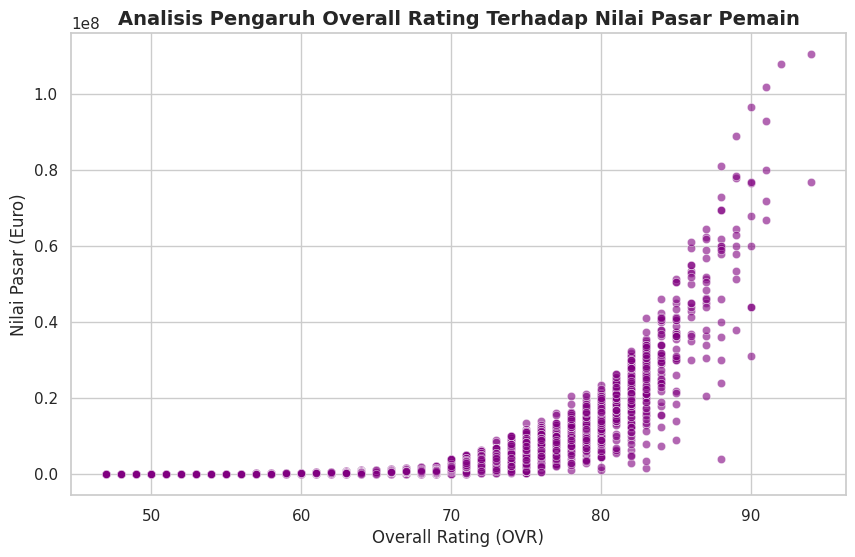

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema grafik
sns.set_theme(style="whitegrid")

# 1. Membuat ukuran kanvas
plt.figure(figsize=(10, 6))

# 2. Membuat Scatter Plot antara Overall Rating dan Value Euro
sns.scatterplot(data=df_fifa, x='overall_rating', y='value_euro', alpha=0.6, color='purple')

# 3. Menambahkan Judul dan Label
plt.title('Analisis Pengaruh Overall Rating Terhadap Nilai Pasar Pemain', fontsize=14, fontweight='bold')
plt.xlabel('Overall Rating (OVR)', fontsize=12)
plt.ylabel('Nilai Pasar (Euro)', fontsize=12)

# 4. Menampilkan grafik
plt.show()

In [11]:
# 1. Menyaring pemain muda (umur <= 21)
df_youngsters = df_fifa[df_fifa['age'] <= 21]

# 2. Mengurutkan berdasarkan potensi tertinggi dan mengambil 10 besar
top_wonderkids = df_youngsters[['name', 'age', 'overall_rating', 'potential', 'value_euro']].sort_values(by='potential', ascending=False).head(30)

# Menampilkan tabel wonderkids
top_wonderkids

,name,age,overall_rating,potential,value_euro
6,K. Mbappé,20,88,95,81000000.0
17837,G. Donnarumma,20,83,94,33500000.0
17839,M. de Ligt,19,83,92,31500000.0
17836,Gabriel Jesus,21,83,92,41000000.0
44,O. Dembélé,21,84,92,46000000.0
191,Vinícius Júnior,18,78,92,20500000.0
17555,J. Sancho,18,79,91,21000000.0
122,H. Aouar,20,80,90,23500000.0
17423,A. Lafont,20,78,90,14000000.0
500,P. Foden,18,75,90,13500000.0


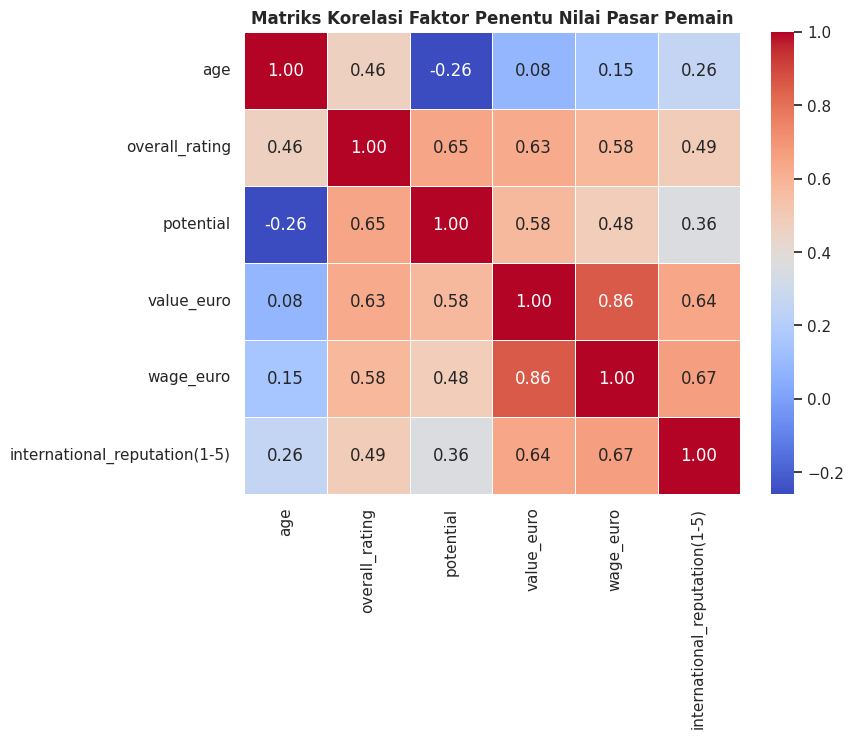

In [12]:
# 1. Memilih beberapa kolom numerik penting untuk dicek korelasinya
kolom_pilihan = ['age', 'overall_rating', 'potential', 'value_euro', 'wage_euro', 'international_reputation(1-5)']
matriks_korelasi = df_fifa[kolom_pilihan].corr()

# 2. Membuat grafik Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Matriks Korelasi Faktor Penentu Nilai Pasar Pemain', fontsize=12, fontweight='bold')
plt.show()

In [13]:
# 1. Membuat kolom baru 'growth'
df_fifa['growth'] = df_fifa['potential'] - df_fifa['overall_rating']

# 2. Menyaring pemain muda (umur <= 21) dan mencari yang memiliki growth tertinggi
top_growth_youngsters = df_fifa[df_fifa['age'] <= 21][['name', 'age', 'overall_rating', 'potential', 'growth', 'value_euro']].sort_values(by='growth', ascending=False).head(15)

# Menampilkan hasil
top_growth_youngsters

,name,age,overall_rating,potential,growth,value_euro
6126,S. Sohm,17,57,83,26,210000.0
6495,J. von Moos,17,58,84,26,280000.0
6140,T. Parrott,17,57,83,26,230000.0
5433,M. Daramy,17,54,80,26,150000.0
7809,A. Riccardi,17,61,86,25,550000.0
5655,B. Mumba,17,55,80,25,190000.0
4546,J. García,17,55,80,25,180000.0
4929,S. Spasov,17,49,74,25,70000.0
5049,H. Geelmuyden,17,51,76,25,80000.0
5345,M. Dewhurst,17,53,77,24,110000.0


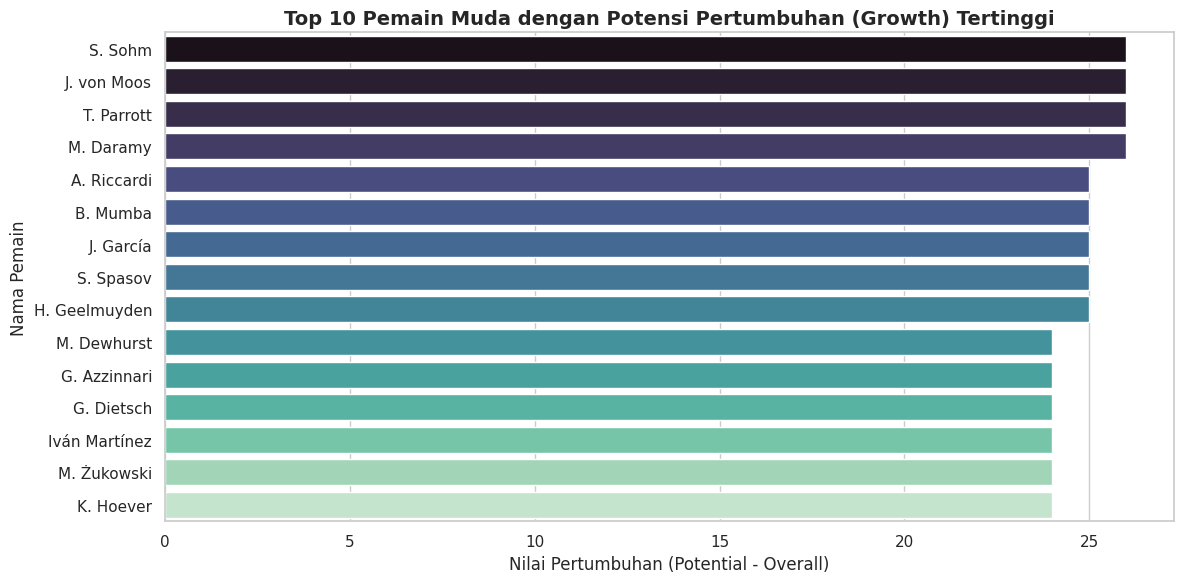

In [14]:
plt.figure(figsize=(12, 6))

# Membuat Bar Plot untuk 10 pemain dengan growth tertinggi
sns.barplot(data=top_growth_youngsters, x='growth', y='name', hue='name', palette='mako', legend=False)

plt.title('Top 10 Pemain Muda dengan Potensi Pertumbuhan (Growth) Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Nilai Pertumbuhan (Potential - Overall)', fontsize=12)
plt.ylabel('Nama Pemain', fontsize=12)

plt.tight_layout()
plt.show()

In [15]:
# Menyeleksi pemain dengan akurasi finishing dan kekuatan tendangan di atas 85
striker_maut = df_fifa[(df_fifa['finishing'] >= 85) & (df_fifa['shot_power'] >= 85)]

# Mengurutkan berdasarkan gabungan kedua skill tersebut dan mengambil 10 besar
top_striker = striker_maut[['name', 'age', 'overall_rating', 'finishing', 'shot_power', 'value_euro']].sort_values(by=['finishing', 'shot_power'], ascending=False).head(20)

# Menampilkan hasil
top_striker

,name,age,overall_rating,finishing,shot_power,value_euro
0,L. Messi,31,94,95,85,110500000.0
17944,Cristiano Ronaldo,34,94,94,95,77000000.0
17937,H. Kane,25,90,94,88,96500000.0
7,S. Agüero,30,89,93,88,64500000.0
17938,L. Suárez,32,91,92,86,80000000.0
17935,R. Lewandowski,30,90,91,88,77000000.0
18,G. Higuaín,31,87,91,86,48500000.0
26,C. Immobile,29,87,90,86,52000000.0
9,E. Cavani,32,89,89,87,60000000.0
17878,E. Džeko,32,85,89,86,30500000.0


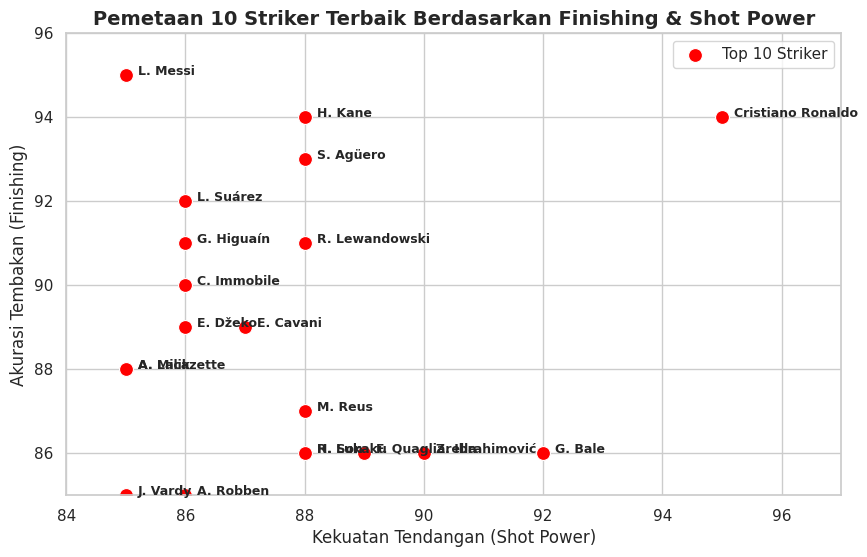

In [16]:
plt.figure(figsize=(10, 6))

# 1. Plot semua penyerang maut sebagai dasar
sns.scatterplot(data=striker_maut, x='shot_power', y='finishing', alpha=0.5, color='gray')

# 2. Plot ulang 10 penyerang teratas dengan warna mencolok dan ukuran lebih besar
sns.scatterplot(data=top_striker, x='shot_power', y='finishing', color='red', s=100, label='Top 10 Striker')

# 3. Memberikan label nama otomatis di samping titik merahnya
for i, txt in enumerate(top_striker['name']):
    plt.annotate(txt, (top_striker['shot_power'].iloc[i]+0.2, top_striker['finishing'].iloc[i]), fontsize=9, fontweight='bold')

plt.title('Pemetaan 10 Striker Terbaik Berdasarkan Finishing & Shot Power', fontsize=14, fontweight='bold')
plt.xlabel('Kekuatan Tendangan (Shot Power)', fontsize=12)
plt.ylabel('Akurasi Tembakan (Finishing)', fontsize=12)
plt.xlim(84, 97)
plt.ylim(85, 96)
plt.legend()
plt.show()

In [17]:
# Mencari data khusus untuk Lionel Messi
data_messi = df_fifa[df_fifa['name'].str.contains('Messi', case=False, na=False)]

# Menampilkan kolom nama, rating, finishing, dan shot power milik Messi
data_messi[['name', 'age', 'overall_rating', 'finishing', 'shot_power', 'value_euro']]

,name,age,overall_rating,finishing,shot_power,value_euro
0,L. Messi,31,94,95,85,110500000.0
12735,Messias,24,68,25,54,1100000.0


In [18]:
# Menyimpan dataset yang sudah bersih dan diperbarui ke file CSV baru
df_fifa.to_csv('fifa_players_clean.csv', index=False)
print("Dataset berhasil disimpan dengan nama 'fifa_players_clean.csv'!")

Dataset berhasil disimpan dengan nama 'fifa_players_clean.csv'!


In [19]:
# A. Mengecek jumlah data yang duplikat
duplicate_count = df_fifa.duplicated().sum()
print(f"Jumlah data duplikat: {duplicate_count}")

# B. Menghapus data duplikat (jika ada) dan memperbarui dataset
# keep='first' artinya jika ada yang sama, baris pertama tetap dipertahankan
df_fifa = df_fifa.drop_duplicates(keep='first')

Jumlah data duplikat: 0


In [20]:
# Membuang spasi kosong di awal/akhir teks dan mengubah menjadi Title Case
df_fifa['name'] = df_fifa['name'].str.strip().str.title()
df_fifa['nationality'] = df_fifa['nationality'].str.strip().str.title()
df_fifa['positions'] = df_fifa['positions'].str.strip().str.upper() # Posisi biasanya UPPERCASE (misal: ST, CM)

print("Formatting data teks selesai!")

Formatting data teks selesai!


In [21]:
df_fifa.head(100)

,name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,value_euro,...,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle,growth
0,L. Messi,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,110500000.0,...,48,22,94,94,75,96,33,28,26,0
1,C. Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,69500000.0,...,46,56,84,91,67,88,59,57,22,1
2,P. Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,73000000.0,...,78,64,82,88,82,87,63,67,67,3
3,L. Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,62000000.0,...,34,26,83,87,61,83,51,24,22,0
4,K. Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,60000000.0,...,87,88,24,49,33,80,91,88,87,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,G. Kondogbia,2/15/1993,26,187.96,79.8,"CM,CDM",Central African Rep.,81,84,22000000.0,...,82,79,77,79,45,82,78,82,82,3
96,J. Roussillon,1/6/1993,26,175.26,79.8,"LB,LWB,LM",France,81,83,18000000.0,...,75,77,71,71,51,75,75,84,79,2
97,S. Zaza,6/25/1991,27,185.42,83.9,ST,Italy,81,82,21000000.0,...,87,40,83,66,79,72,54,42,50,1
98,S. Vrsaljko,1/10/1992,27,154.94,76.2,RB,Croatia,81,81,15000000.0,...,75,80,65,68,52,67,79,81,77,0


In [22]:
# A. Membuat fitur rasio harga per poin rating
df_fifa['value_per_ovr'] = df_fifa['value_euro'] / df_fifa['overall_rating']

# B. Membuat fungsi untuk mengkategorikan usia
def membuat_kategori_usia(umur):
    if umur <= 21:
        return 'Wonderkid (<=21)'
    elif umur <= 29:
        return 'Golden Age (22-29)'
    else:
        return 'Veteran (>=30)'

# Menerapkan fungsi ke dalam kolom baru
df_fifa['age_category'] = df_fifa['age'].apply(membuat_kategori_usia)

# C. Hitung ulang fitur growth yang sebelumnya
df_fifa['growth'] = df_fifa['potential'] - df_fifa['overall_rating']

In [23]:
# Mengaktifkan tabel interaktif
%load_ext google.colab.data_table

# Menampilkan data untuk memastikan kolom baru sudah muncul di paling kanan
df_fifa[['name', 'age', 'age_category', 'overall_rating', 'growth', 'value_per_ovr']].head(100)

,name,age,age_category,overall_rating,growth,value_per_ovr
0,L. Messi,31,Veteran (>=30),94,0,1.175532e+06
1,C. Eriksen,27,Golden Age (22-29),88,1,7.897727e+05
2,P. Pogba,25,Golden Age (22-29),88,3,8.295455e+05
3,L. Insigne,27,Golden Age (22-29),88,0,7.045455e+05
4,K. Koulibaly,27,Golden Age (22-29),88,3,6.818182e+05
...,...,...,...,...,...,...
95,G. Kondogbia,26,Golden Age (22-29),81,3,2.716049e+05
96,J. Roussillon,26,Golden Age (22-29),81,2,2.222222e+05
97,S. Zaza,27,Golden Age (22-29),81,1,2.592593e+05
98,S. Vrsaljko,27,Golden Age (22-29),81,0,1.851852e+05


In [24]:
# Urutkan berdasarkan overall_rating terbesar, lalu tampilkan 10 baris teratas
df_fifa[['name', 'age', 'age_category', 'overall_rating', 'growth', 'value_per_ovr']].sort_values(by='overall_rating', ascending=False).head(100)

,name,age,age_category,overall_rating,growth,value_per_ovr
0,L. Messi,31,Veteran (>=30),94,0,1.175532e+06
17944,Cristiano Ronaldo,34,Veteran (>=30),94,0,8.191489e+05
17943,Neymar Jr,27,Golden Age (22-29),92,0,1.173913e+06
17938,L. Suárez,32,Veteran (>=30),91,0,8.791209e+05
17940,E. Hazard,28,Golden Age (22-29),91,0,1.021978e+06
...,...,...,...,...,...,...
17871,Pepe,36,Veteran (>=30),85,0,1.058824e+05
45,Iniesta,34,Veteran (>=30),85,0,2.176471e+05
17874,B. Matuidi,31,Veteran (>=30),85,0,3.058824e+05
17885,Paulinho,30,Veteran (>=30),85,0,4.352941e+05
